In [ ]:
import pandas as pd

In [7]:
df = pd.read_csv('/content/sample_data/advertising.csv')

In [8]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [9]:
df.head()

,TV,Radio,Newspaper,Sales
0,230.1,37.8,69.2,22.1
1,44.5,39.3,45.1,10.4
2,17.2,45.9,69.3,12.0
3,151.5,41.3,58.5,16.5
4,180.8,10.8,58.4,17.9


In [10]:
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 4 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   TV         200 non-null    float64
 1   Radio      200 non-null    float64
 2   Newspaper  200 non-null    float64
 3   Sales      200 non-null    float64
dtypes: float64(4)
memory usage: 6.4 KB


In [11]:
df.isnull().sum()

,0
TV,0
Radio,0
Newspaper,0
Sales,0


In [12]:
df.shape

(200, 4)

In [13]:
df.columns

Index(['TV', 'Radio', 'Newspaper', 'Sales'], dtype='object')

In [14]:
df.duplicated().sum()

np.int64(0)

In [15]:
df.describe()

,TV,Radio,Newspaper,Sales
count,200.000000,200.000000,200.000000,200.000000
mean,147.042500,23.264000,30.554000,15.130500
std,85.854236,14.846809,21.778621,5.283892
min,0.700000,0.000000,0.300000,1.600000
25%,74.375000,9.975000,12.750000,11.000000
50%,149.750000,22.900000,25.750000,16.000000
75%,218.825000,36.525000,45.100000,19.050000
max,296.400000,49.600000,114.000000,27.000000


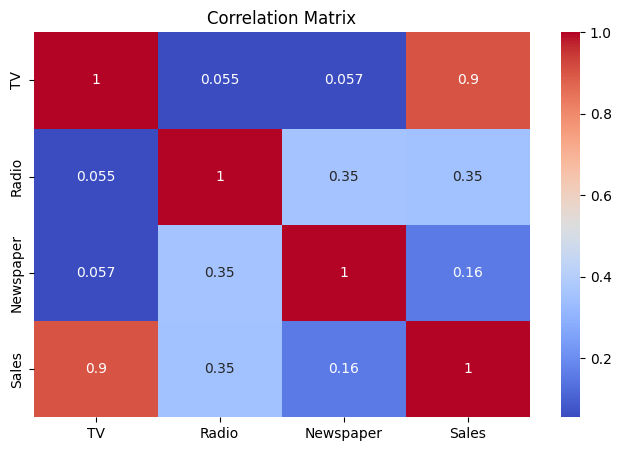

In [16]:
plt.figure(figsize=(8, 5))

sns.heatmap(df.corr(), annot=True, cmap='coolwarm')

plt.title('Correlation Matrix')
plt.show()

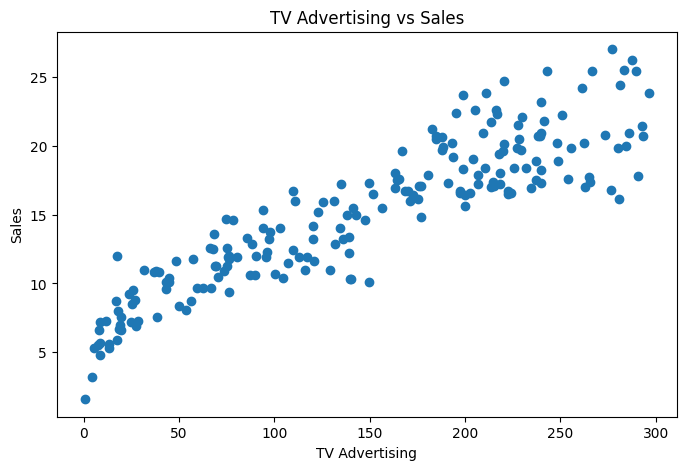

In [17]:
#TV AD VS SALES
plt.figure(figsize=(8, 5))

plt.scatter(df['TV'], df['Sales'])

plt.xlabel('TV Advertising')
plt.ylabel('Sales')
plt.title('TV Advertising vs Sales')

plt.show()

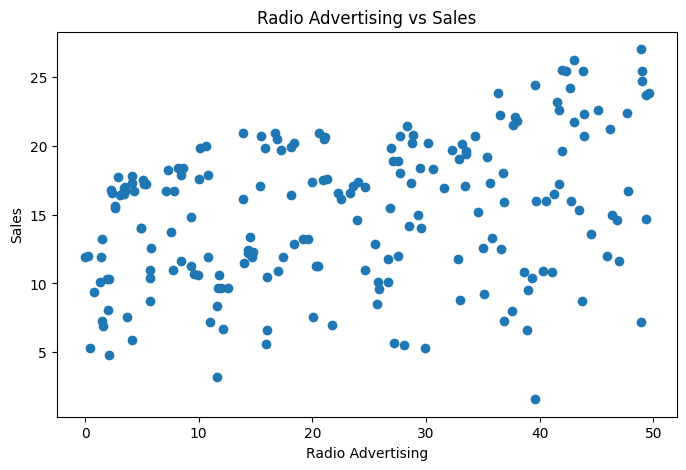

In [18]:
#radio ad vs sales
plt.figure(figsize=(8, 5))

plt.scatter(df['Radio'], df['Sales'])

plt.xlabel('Radio Advertising')
plt.ylabel('Sales')
plt.title('Radio Advertising vs Sales')

plt.show()

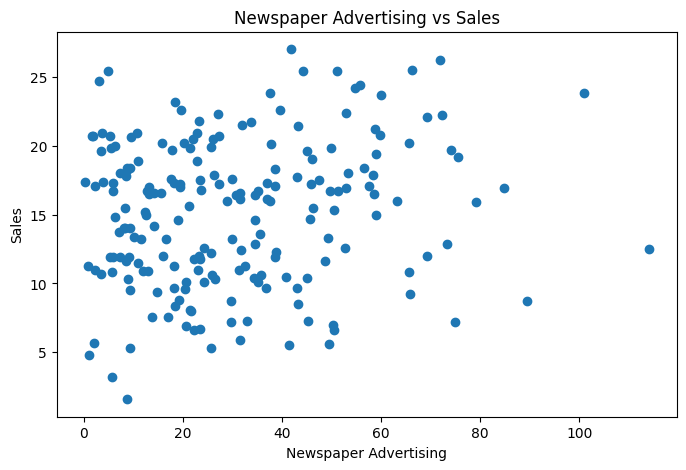

In [19]:
#Newspaper ad vs sales
plt.figure(figsize=(8, 5))

plt.scatter(df['Newspaper'], df['Sales'])

plt.xlabel('Newspaper Advertising')
plt.ylabel('Sales')
plt.title('Newspaper Advertising vs Sales')

plt.show()

In [20]:
X = df[['TV', 'Radio', 'Newspaper']]
y = df['Sales']

In [21]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [22]:
from sklearn.linear_model import LinearRegression

In [23]:
model = LinearRegression()

In [24]:
model.fit(X_train, y_train)
y_pred = model.predict(X_test)

In [25]:
comparison = pd.DataFrame({
    'Actual Sales': y_test.values,
    'Predicted Sales': y_pred
})

comparison.head(10)

,Actual Sales,Predicted Sales
0,16.9,17.034772
1,22.4,20.409740
2,21.4,23.723989
3,7.3,9.272785
4,24.7,21.682719
5,12.6,12.569402
6,22.3,21.081195
7,8.4,8.690350
8,16.5,17.237013
9,16.1,16.666575


In [26]:
#Cal. absolute errors
from sklearn.metrics import mean_absolute_error

mae = mean_absolute_error(y_test, y_pred)

print("Mean Absolute Error:", mae)

Mean Absolute Error: 1.2748262109549338


In [27]:
#mean squared error
from sklearn.metrics import mean_squared_error

mse = mean_squared_error(y_test, y_pred)

print("Mean Squared Error:", mse)

Mean Squared Error: 2.9077569102710896


In [28]:
from sklearn.metrics import r2_score

r2 = r2_score(y_test, y_pred)

print("R² Score:", r2)

R² Score: 0.9059011844150826


In [29]:
print("Mean Absolute Error:", mae)
print("Mean Squared Error:", mse)
print("R² Score:", r2)

Mean Absolute Error: 1.2748262109549338
Mean Squared Error: 2.9077569102710896
R² Score: 0.9059011844150826


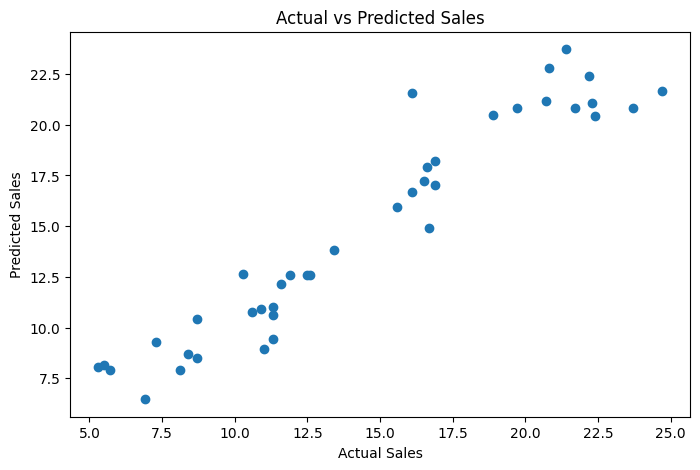

In [30]:
plt.figure(figsize=(8, 5))

plt.scatter(y_test, y_pred)

plt.xlabel('Actual Sales')
plt.ylabel('Predicted Sales')
plt.title('Actual vs Predicted Sales')

plt.show()

In [31]:
print("Intercept:", model.intercept_)
print("Coefficients:", model.coef_)

Intercept: 4.714126402214127
Coefficients: [0.05450927 0.10094536 0.00433665]


In [34]:
#Sales prediction
new_data = pd.DataFrame({
    'TV': [200],
    'Radio': [50],
    'Newspaper': [30]
})

prediction = model.predict(new_data)

print("Predicted Sales:", prediction[0])

Predicted Sales: 20.793348093966895


In [35]:
def predict_sales(tv, radio, newspaper):
    new_data = pd.DataFrame({
        'TV': [tv],
        'Radio': [radio],
        'Newspaper': [newspaper]
    })

    prediction = model.predict(new_data)

    return prediction[0]

In [36]:
predict_sales(200, 40, 30)

np.float64(19.783894470037335)